# ***Final Assignment: X-Ray images classification***
---
*   Meri Ferretti (10666970)
*   Diana Nigrisoli (10824967)
*   Laura Pozzi (10868694)

In this first script all the steps related to ***data investigation*** and preliminary ***dataset preparation*** will be illustrated.

---



### Mounting | Importing | Seed

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
%cd /content/drive/MyDrive/Lab_Applied_AI/Applied_AI_project

/content/drive/MyDrive/Lab_Applied_AI/Applied_AI_project


In [7]:
import os
import sys
import cv2
import math
import json
import random
import shutil
import tarfile
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.patches as patches
import tensorflow as tf
tfk = tf.keras
tfkl = tf.keras.layers
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import Dense,Flatten,Input,Lambda,GlobalAveragePooling2D,Dropout,Conv2D,BatchNormalization,MaxPooling2D,Input,Activation
from tensorflow.keras.models import load_model,Model,Sequential
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator,load_img,img_to_array,array_to_img
from tensorflow.keras.optimizers import Adam,RMSprop,SGD
from tensorflow.keras.applications.densenet import DenseNet169, preprocess_input
from tensorflow.keras.callbacks import ModelCheckpoint,EarlyStopping,ReduceLROnPlateau
from tensorflow.keras.regularizers import l2
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from sklearn.metrics import confusion_matrix, classification_report
from collections import Counter, defaultdict
from glob import glob
from PIL import Image
plt.rc('font', size=16) 

In [4]:
### Random seed for reproducibility
seed = 42   

random.seed(seed)
os.environ['PYTHONHASHSEED'] = str(seed)
np.random.seed(seed)
tf.random.set_seed(seed)
tf.compat.v1.set_random_seed(seed)

### CSV File Inspection

In [ ]:
### Functions definition

def plot_class_distribution(y: pd.DataFrame) -> None:
    plt.figure(figsize = (10,7))
    sns.countplot(x="label", data=y)
    plt.show()
    
def division_per_class(x,y,class_name,n_sample = None):
  return x[y==MAPPING[class_name]] 

In [ ]:
### Creating a pandas dataframe to read the .csv file
labels = pd.read_csv('/content/drive/My Drive/Lab_Applied_AI/Applied_AI_project/labels_train.csv')
labels_df = pd.DataFrame(labels)
labels_df.head()

,file,label
0,P00001_1.png,N
1,P00001_2.png,N
2,P00002_1.png,N
3,P00003_1.png,N
4,P00004_1.jpeg,N


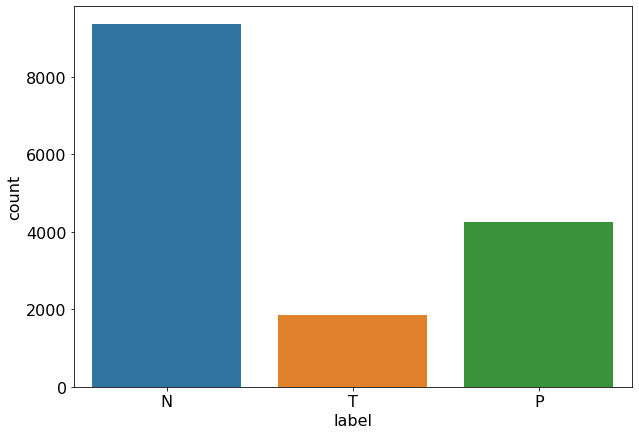

In [ ]:
plot_class_distribution(labels_df)

In [ ]:
### Converting each of the 2 columns of the dataframe into numpy arrays
y = labels_df["label"]
x = labels_df["file"]

y_array = y.to_numpy()
print('Label array dimension:', y_array.shape)
x_array = x.to_numpy()
print('File name array dimension:', x_array.shape)
# Classes contained in the label array
print('Classes are:', np.unique(y_array))

Label array dimension: (15470,)
File name array dimension: (15470,)
Classes are: ['N' 'P' 'T']


In [ ]:
### Classes names mapping 
CLASSES = len(np.unique(y))

MAPPING = {
    "Normal": "N",
    "Pneumonia": "P",
    "Tuberculosis": "T",
}

print('Number of classes:', CLASSES)
print(MAPPING)

Number of classes: 3
{'Normal': 'N', 'Pneumonia': 'P', 'Tuberculosis': 'T'}


In [ ]:
### Dividing samples names according to their label
normal = division_per_class(x_array,y_array,"Normal")
pneumo = division_per_class(x_array,y_array,"Pneumonia")
tube = division_per_class(x_array,y_array,"Tuberculosis")

In [ ]:
print('Normal:', normal.size)
print('Pneumonia:', pneumo.size)
print('Tuberculosis:', tube.size)

Normal: 9354
Pneumonia: 4250
Tuberculosis: 1866


**Checking if there are patients associated to multiple classes**

In [ ]:
# These lists will include patients code repeated as many times as the images of that patient 
# appears in the selected class group 
patients = []
patients_norm = []
patients_pneumo = []
patients_tube = []

for sample in normal:
    patients.append(sample[:6])
    patients_norm.append(sample[:6])
    
for sample in tube:
    patients.append(sample[:6])
    patients_tube.append(sample[:6])

for sample in pneumo:
    patients.append(sample[:6])
    patients_pneumo.append(sample[:6])

print('Total:', len(patients))
print('Normal:', len(patients_norm))
print('Pneumonia:', len(patients_pneumo))
print('Tuberculosis:', len(patients_tube))

Total: 15470
Normal: 9354
Pneumonia: 4250
Tuberculosis: 1866


In [ ]:
print('Number of patients belonging to more than one class...')

i = 0
double1 = []
for tmp in patients_norm:
    if tmp in patients_pneumo:
        if (tmp in double1) == False:
            double1.append(tmp)


double2 = []
for tmp in patients_tube:
    if tmp in patients_pneumo:
        if (tmp in double2) == False:
            double2.append(tmp)


double3 = []
for tmp in patients_norm:
    if tmp in patients_tube:
        if (tmp in double3) == False:
            double3.append(tmp)

print(len(double1) + len(double2) + len(double3))
# Each patient belongs to one class only!

Number of patients belonging to more than one class...
0


**Checking if a patient occures more than one time in the same class**


In [ ]:
(unique, counts) = np.unique(patients_norm, return_counts=True)
frequencies = np.asarray((unique, counts)).T
unique[counts>1]
print("Number of patients appearing more than once in the same class:")
print("Normal: " + str(unique[counts>1].size))

(unique, counts) = np.unique(patients_tube, return_counts=True)
frequencies = np.asarray((unique, counts)).T
unique[counts>1]
print("Tuberculosis: " + str(unique[counts>1].size))

(unique, counts) = np.unique(patients_pneumo, return_counts=True)
frequencies = np.asarray((unique, counts)).T
unique[counts>1]
print("Pneumonia: " + str(unique[counts>1].size))

Number of patients appearing more than once in the same class:
Normal: 2033
Tuberculosis: 406
Pneumonia: 945


In [ ]:
unique_patients = np.unique(patients)
print('Total amount of patients:', len(unique_patients))

Total amount of patients: 12086


### Creation of a preliminary dataset containing resized images

N.B. ***We DO NOT recommend to run this section cause it could last a huge amount of time***

In [ ]:
### Functions definition

def create_folder_per_class(source_dir,normal_images,normal_dir,tube_images,tube_dir,pneumo_images,pneumo_dir):
    os.makedirs(normal_dir , exist_ok=True)
    os.makedirs(tube_dir , exist_ok=True)
    os.makedirs(pneumo_dir , exist_ok=True)
    # iterate on all files to move them to destination folder
    for f in normal_images:
        shutil.move(source_dir + '/' + f, normal_dir + '/' + f )

    for f in tube_images:
        shutil.move(source_dir + '/' + f, tube_dir + '/' + f )

    for f in pneumo_images:
        shutil.move(source_dir + '/' + f, pneumo_dir + '/' + f )

def resize_all(image_folder, save_folder, size):
    if not os.path.isdir(save_folder):
        os.mkdir(save_folder)
    for img_path in os.listdir(image_folder):
        img = cv2.imread(f"{image_folder}/{img_path}")
        img = cv2.resize(img, (size, size))
        cv2.imwrite(f"{save_folder}/{img_path}", img)


In [ ]:
### Creating new folders divided per classes
source_dir = '/content/drive/MyDrive/Lab_Applied_AI/Applied_AI_project/All_data'

normal_dir = '/content/drive/MyDrive/Lab_Applied_AI/Applied_AI_project/DataDivided/Normal'
tube_dir = '/content/drive/My Drive/Lab_Applied_AI/Applied_AI_project/DataDivided/Tuberculosis'
pneumo_dir = '/content/drive/My Drive/Lab_Applied_AI/Applied_AI_project/DataDivided/Pneumonia'

In [ ]:
create_folder_per_class(source_dir,normal,normal_dir,tube,tube_dir,pneumo,pneumo_dir)

In [ ]:
### Resizing all images
normal_dir_res = '/content/drive/MyDrive/Lab_Applied_AI/Applied_AI_project/DataDivided_resized/Normal'
tube_dir_res = '/content/drive/My Drive/Lab_Applied_AI/Applied_AI_project/DataDivided_resized/Tuberculosis'
pneumo_dir_res = '/content/drive/My Drive/Lab_Applied_AI/Applied_AI_project/DataDivided_resized/Pneumonia'

In [ ]:
resize_all(normal_dir,normal_dir_res,256)
resize_all(tube_dir,tube_dir_res,256)
resize_all(pneumo_dir,pneumo_dir_res,256)

### Image Inspection 

#### 1 - Visualizing the different classes





In [ ]:
path = '/content/drive/My Drive/Lab_Applied_AI/Applied_AI_project/DataDivided_resized'
normal_img = Image.open(os.path.join(path, 'Normal', normal[random.randint(0,len(normal))]))
pneumo_img = Image.open(os.path.join(path, 'Pneumonia', pneumo[random.randint(0,len(pneumo))]))
tube_img = Image.open(os.path.join(path, 'Tuberculosis', tube[random.randint(0,len(tube))]))

(-0.5, 255.5, 255.5, -0.5)

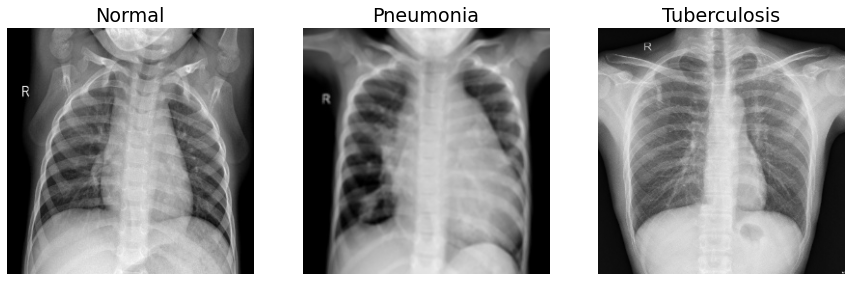

In [ ]:
fig, axs = plt.subplots(1, 3, figsize=(15,30))
axs[0].imshow(normal_img, cmap='gray')
axs[0].set_title('Normal')
axs[0].axis('off')
axs[1].imshow(pneumo_img, cmap='gray')
axs[1].set_title('Pneumonia')
axs[1].axis('off')
axs[2].imshow(tube_img, cmap='gray')
axs[2].set_title('Tuberculosis')
axs[2].axis('off')

#### 2 - Visualizing the two formats

In [5]:
path = '/content/drive/My Drive/Lab_Applied_AI/Applied_AI_project/DataDivided_resized'
standard = Image.open(os.path.join(path, 'Normal', 'P10814_1.png'))
negative = Image.open(os.path.join(path, 'Normal', 'P10814_2.png'))

(-0.5, 255.5, 255.5, -0.5)

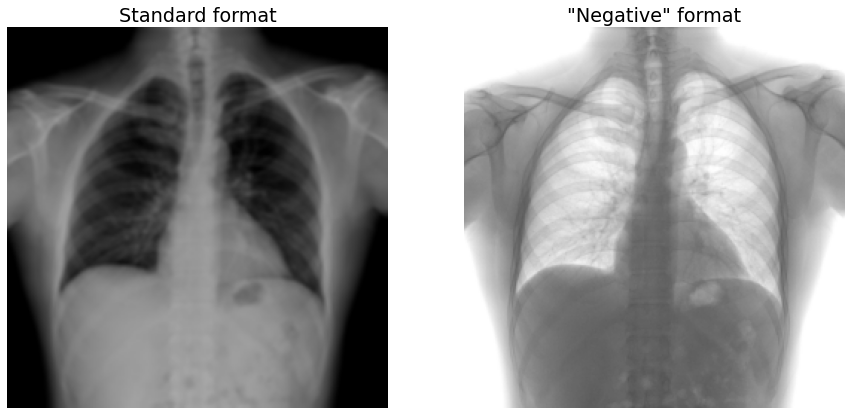

In [8]:
fig, axs = plt.subplots(1, 2, figsize=(15,30))
axs[0].imshow(standard, cmap='gray')
axs[0].set_title('Standard format')
axs[0].axis('off')
axs[1].imshow(negative, cmap='gray')
axs[1].set_title('"Negative" format')
axs[1].axis('off')

#### 3 - Visualizing noisy samples 

In [ ]:
path = '/content/drive/My Drive/Lab_Applied_AI/Applied_AI_project/DataDivided_resized'
salt_and_pepper = Image.open(os.path.join(path, 'Normal', 'P00030_1.png'))
uniform = Image.open(os.path.join(path, 'Normal', 'P00035_1.png'))
black_spots = Image.open(os.path.join(path, 'Normal', 'P00038_1.png'))

(-0.5, 255.5, 255.5, -0.5)

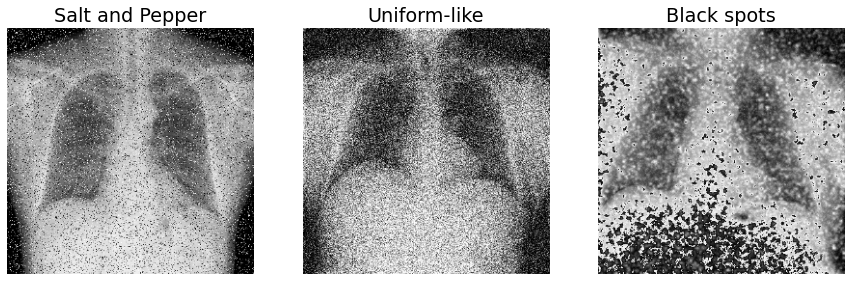

In [ ]:
fig, axs = plt.subplots(1, 3, figsize=(15,30))
axs[0].imshow(salt_and_pepper, cmap='gray')
axs[0].set_title('Salt and Pepper')
axs[0].axis('off')
axs[1].imshow(uniform, cmap='gray')
axs[1].set_title('Uniform-like')
axs[1].axis('off')
axs[2].imshow(black_spots, cmap='gray')
axs[2].set_title('Black spots')
axs[2].axis('off')

### ROIs for preprocessing

In [65]:
### Defining ROIs coordinates
img_size = 256 # image height = image width
roi_size = 10 # ROI height = ROI width

# roi 1 (top-left)
w1_start = 4
h1_start = 32
# roi 2 (top-right)
w2_start = img_size - 4 - roi_size
h2_start = 4
# roi 3 (center-right)
w3_start = img_size - 4 - roi_size
h3_start = 120
# roi 4 (bottom-right)
w4_start = img_size - 4 - roi_size
h4_start = img_size - 32 - roi_size
# roi 5 (bottom-left)
w5_start = 4
h5_start = img_size - 4 - roi_size
# roi 6 (center-left)
w6_start = 4
h6_start = 120

#### 1 - ROIs Visualization

In [9]:
### Loading resized images 
normal_dir = '/content/drive/MyDrive/Lab_Applied_AI/Applied_AI_project/DataDivided_resized/Normal'
tube_dir = '/content/drive/My Drive/Lab_Applied_AI/Applied_AI_project/DataDivided_resized/Tuberculosis'
pneumo_dir = '/content/drive/My Drive/Lab_Applied_AI/Applied_AI_project/DataDivided_resized/Pneumonia'

In [75]:
def plot_sample_and_roi(data_dir):
  num_row = 1
  num_col = 7
  fig, axes = plt.subplots(num_row, num_col, figsize=(8*num_col,10*num_row))
  index = 0
  act_colum = 0
  
  img = cv2.imread(data_dir)
  
  ax_1 = axes[0]
  ax_1.imshow(img,cmap="gray")
  ax_1.axis('off')

  #1.rect creation
  rect1 = patches.Rectangle((w1_start, h1_start), roi_size, roi_size, linewidth=2, edgecolor='r', facecolor='none')
  rect2 = patches.Rectangle((w2_start, h2_start), roi_size, roi_size, linewidth=2, edgecolor='r', facecolor='none')
  rect3 = patches.Rectangle((w3_start, h3_start), roi_size, roi_size, linewidth=2, edgecolor='r', facecolor='none')
  rect4 = patches.Rectangle((w4_start, h4_start), roi_size, roi_size, linewidth=2, edgecolor='r', facecolor='none')
  rect5 = patches.Rectangle((w5_start, h5_start), roi_size, roi_size, linewidth=2, edgecolor='r', facecolor='none')
  rect6 = patches.Rectangle((w6_start, h6_start), roi_size, roi_size, linewidth=2, edgecolor='r', facecolor='none')

  ax_1.add_patch(rect1)
  ax_1.add_patch(rect2)
  ax_1.add_patch(rect3)
  ax_1.add_patch(rect4)
  ax_1.add_patch(rect5)
  ax_1.add_patch(rect6)

  #2.second image: roi1
  ax_2 = axes[1]
  roi1 = img[h1_start:h1_start+roi_size, w1_start:w1_start+roi_size]
  std = round(roi1.std(),1)
  mean = round(roi1.mean(),1)
  ax_2.imshow(roi1, cmap="gray")
  ax_2.set_title('std: {}\nmean: {}'.format(std, mean), fontsize = 24)
  ax_2.axis('off')

  #3.third image: roi2
  ax_3 = axes[2]
  roi2 = img[h2_start:h2_start+roi_size, w2_start:w2_start+roi_size]
  std = round(roi2.std(),1)
  mean = round(roi2.mean(),1)
  ax_3.imshow(roi2, cmap="gray")
  ax_3.set_title('std: {}\nmean: {}'.format(std, mean), fontsize = 24)
  ax_3.axis('off')

  #4 th image: roi3
  ax_4 = axes[3]
  roi3 = img[h3_start:h3_start+roi_size, w3_start:w3_start+roi_size] 
  std = round(roi3.std(),1)
  mean = round(roi3.mean(),1)
  ax_4.imshow(roi3, cmap="gray")
  ax_4.set_title('std: {}\nmean: {}'.format(std, mean), fontsize = 24)
  ax_4.axis('off')

  #5 th image: roi4
  ax_5 = axes[4]
  roi4 = img[h4_start:h4_start+roi_size, w4_start:w4_start+roi_size, ]
  std = round(roi4.std(),1)
  mean = round(roi4.mean(),1)
  ax_5.imshow(roi4, cmap="gray")
  ax_5.set_title('std: {}\nmean: {}'.format(std, mean), fontsize = 24)
  ax_5.axis('off')

  #6 th image: roi5
  ax_6 = axes[5]
  roi5 = img[h5_start:h5_start+roi_size, w5_start:w5_start+roi_size] 
  std = round(roi5.std(),1)
  mean = round(roi5.mean(),1)
  ax_6.imshow(roi5, cmap="gray")
  ax_6.set_title('std: {}\nmean: {}'.format(std, mean), fontsize = 24)
  ax_6.axis('off')

  #7 th image: roi6
  ax_7 = axes[6]
  roi6 = img[h6_start:h6_start+roi_size, w6_start:w6_start+roi_size] 
  std = round(roi6.std(),1)
  mean = round(roi6.mean(),1)
  ax_7.imshow(roi6, cmap="gray")
  ax_7.set_title('std: {}\nmean: {}'.format(std, mean), fontsize = 24)
  ax_7.axis('off')


def plot_overimposed_roi(img_dir):
  
  img = cv2.imread(img_dir)
  fig, ax = plt.subplots(1,1,figsize=(5,5))
  ax.imshow(img,cmap="gray")
  ax.axis('off')

  rect1 = patches.Rectangle((w1_start, h1_start), roi_size, roi_size, linewidth=2, edgecolor='r', facecolor='none')
  rect2 = patches.Rectangle((w2_start, h2_start), roi_size, roi_size, linewidth=2, edgecolor='r', facecolor='none')
  rect3 = patches.Rectangle((w3_start, h3_start), roi_size, roi_size, linewidth=2, edgecolor='r', facecolor='none')
  rect4 = patches.Rectangle((w4_start, h4_start), roi_size, roi_size, linewidth=2, edgecolor='r', facecolor='none')
  rect5 = patches.Rectangle((w5_start, h5_start), roi_size, roi_size, linewidth=2, edgecolor='r', facecolor='none')
  rect6 = patches.Rectangle((w6_start, h6_start), roi_size, roi_size, linewidth=2, edgecolor='r', facecolor='none')

  ax.add_patch(rect1)
  ax.add_patch(rect2)
  ax.add_patch(rect3)
  ax.add_patch(rect4)
  ax.add_patch(rect5)
  ax.add_patch(rect6)

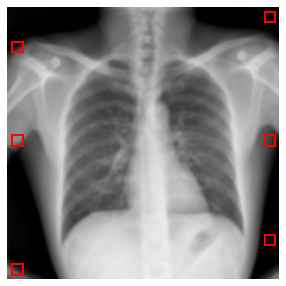

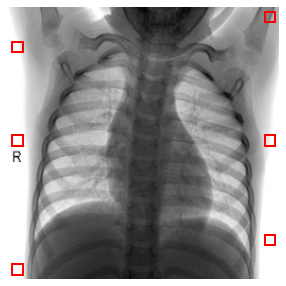

In [93]:
# Examples:
img1_dir = os.path.join(normal_dir, 'P00303_1.png')
img2_dir = os.path.join(normal_dir, 'P10952_1.jpeg')

plot_overimposed_roi(img1_dir)
plot_overimposed_roi(img2_dir)

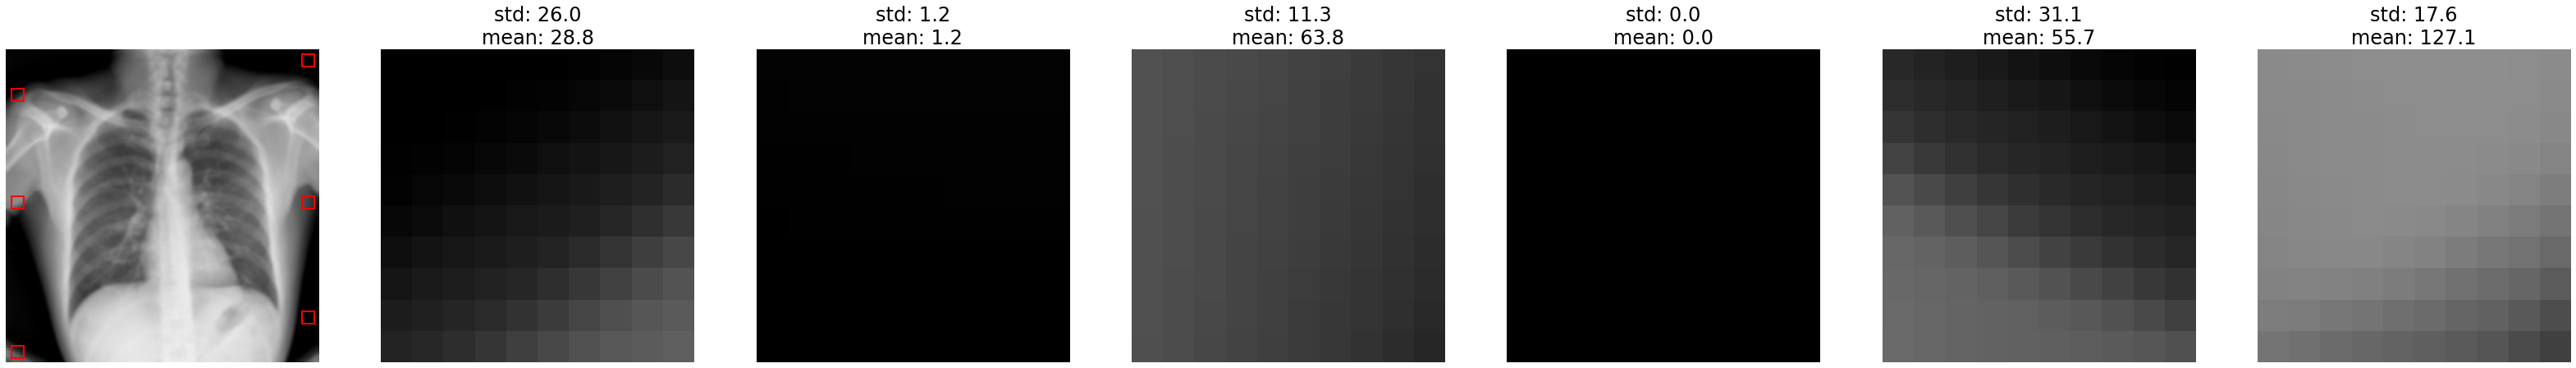

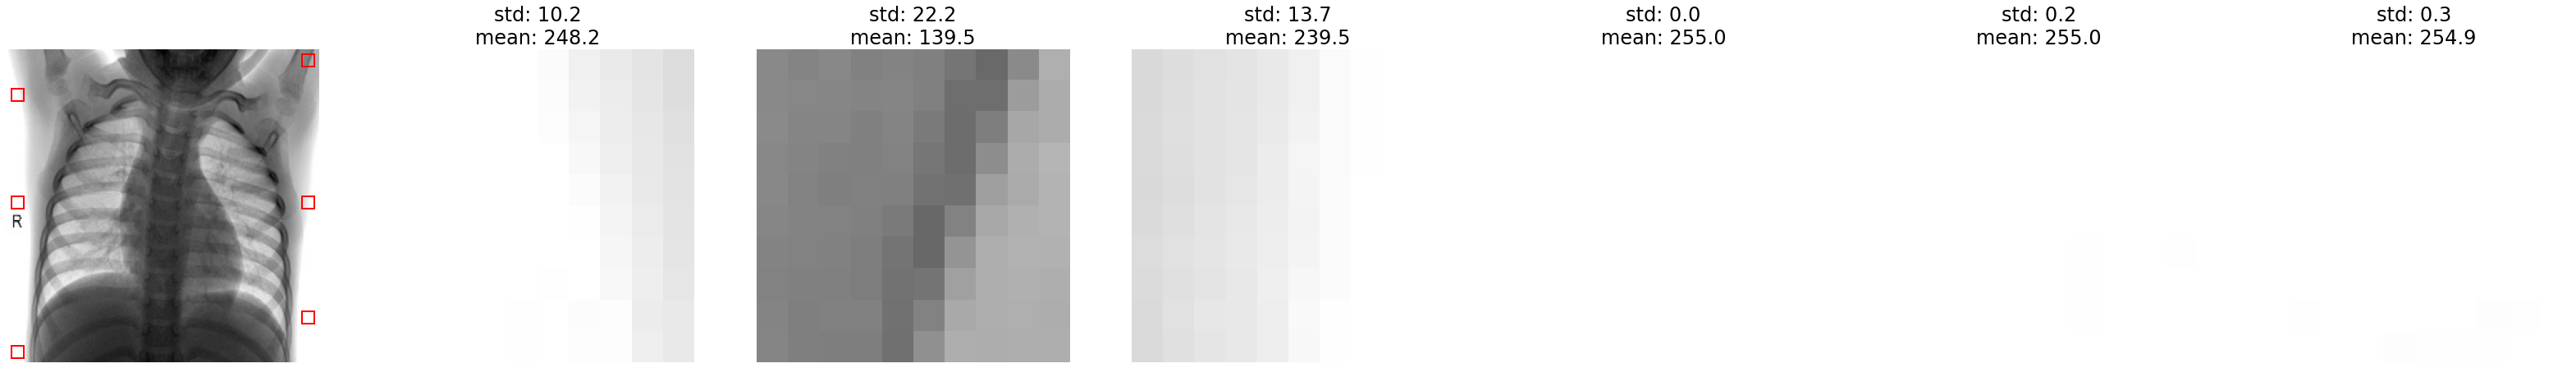

In [94]:
plot_sample_and_roi(img1_dir)
plot_sample_and_roi(img2_dir)

#### 2 - Noisy and White Images


In [ ]:
def check_noise(img):
  
  roi1 = img[h1_start:h1_start+roi_size, w1_start:w1_start+roi_size]
  std1 = roi1.std()
  
  roi2 = img[h2_start:h2_start+roi_size, w2_start:w2_start+roi_size]
  std2 = roi2.std()
 
  roi3 = img[h3_start:h3_start+roi_size, w3_start:w3_start+roi_size]
  std3 = roi3.std()
  
  roi4 = img[h4_start:h4_start+roi_size, w4_start:w4_start+roi_size]
  std4 = roi4.std()

  roi5 = img[h5_start:h5_start+roi_size, w5_start:w5_start+roi_size]
  std5 = roi5.std()

  roi6 = img[h6_start:h6_start+roi_size, w6_start:w6_start+roi_size]
  std6 = roi6.std()

  if (std1>20 and std2>20 and std3>20 and std4>20 and std5>20 and std6>20):
    return 1

  else: 
    return 0

#*******************************************************************************
def check_white(img): #check one image at a time
  
  roi1 = img[h1_start:h1_start+roi_size, w1_start:w1_start+roi_size]
  mean1 = roi1.mean()

  roi2 = img[h2_start:h2_start+roi_size, w2_start:w2_start+roi_size]
  mean2 = roi2.mean()

  roi3 = img[h3_start:h3_start+roi_size, w3_start:w3_start+roi_size]
  mean3 = roi3.mean()

  roi4 = img[h4_start:h4_start+roi_size, w4_start:w4_start+roi_size]
  mean4 = roi4.mean()

  roi5 = img[h5_start:h5_start+roi_size, w5_start:w5_start+roi_size]
  mean5 = roi5.mean()

  roi6 = img[h6_start:h6_start+roi_size, w6_start:w6_start+roi_size]
  mean6 = roi6.mean()

  if (mean4>240): img_returned = 1 # white background
  elif (mean1>208 or mean2>208 or mean3>208 or mean4>208 or mean5>208 or mean6>208):
    if sum([mean < 85 for mean in(mean1,mean2,mean3,mean4,mean5,mean6)]) >=2: 
      img_returned = 0 # black background
    else : img_returned = 1 # white background
  else:
    img_returned = 0 # black background

  return img_returned


#*******************************************************************************
def count_negative_and_noisy(data_class, img_class_dir):

  i=0

  negative_counter=0
  noisy_counter=0

  for i in range(len(data_class)): 
    
    image_path = os.path.join(img_class_dir,data_class[i])
    image = cv2.imread(image_path)
  
    x = check_noise(image)
    y = check_white(image)

    if(x==1):
      noisy_counter+=1
    
    if (y==1): 
      negative_counter+=1

  return noisy_counter, negative_counter


In [ ]:
noisy_norm, negative_norm = count_negative_and_noisy (normal, normal_dir_res)
noisy_pneumo, negative_pneumo = count_negative_and_noisy (pneumo, pneumo_dir_res)
noisy_tube, negative_tube = count_negative_and_noisy (tube, tube_dir_res)

In [ ]:
noisy_tot = noisy_norm + noisy_tube + noisy_pneumo
print('Noisy: '+ str(noisy_tot) )

Noisy: 3056


In [ ]:
white_tot = negative_norm + negative_tube + negative_pneumo
print('White: '+ str(white_tot) )

White: 2651


### Equalization effect

In [78]:
def equalize(image):

  grayimg = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
  grayimg = np.uint8(grayimg)
  # Equalizing each channel individually
  image_eq = cv2.equalizeHist(grayimg)
 
  # Stacking the equalized channels back into a single image
  image_equal = np.stack((image_eq,image_eq,image_eq), axis=2)

  return image_equal

In [79]:
def showimage(myimage, figsize = [5,5]):
    if (myimage.ndim>2):  #This only applies to RGB or RGBA images (e.g. not to Black and White images)
        myimage = myimage[:,:,::-1] #OpenCV follows BGR order, while matplotlib likely follows RGB order
         
    fig, ax = plt.subplots(figsize=figsize)
    ax.imshow(myimage, cmap = 'gray', interpolation = 'bicubic')
    plt.xticks([]), plt.yticks([])  # to hide tick values on X and Y axis
    plt.show()

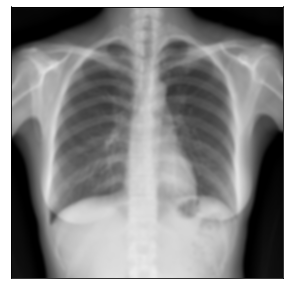

In [80]:
colorimage = cv2.imread('/content/drive/MyDrive/Lab_Applied_AI/Applied_AI_project/DataDivided_resized/Normal/P00006_2.png')
showimage(colorimage)

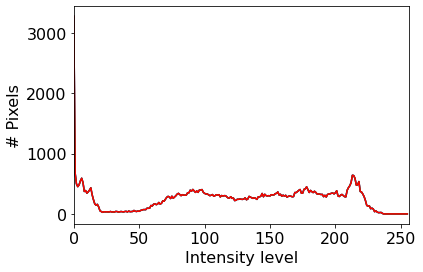

In [87]:
# Histograms
color = ('b','g','r')
for i,col in enumerate(color):
    histr = cv2.calcHist([colorimage],[i],None,[256],[0,256])
    plt.plot(histr,color = col)
    plt.xlim([0,256])
    plt.xlabel('Intensity level')
    plt.ylabel('# Pixels')
plt.show()

hist = cv2.calcHist([colorimage],[0],None,[256],[0,256])

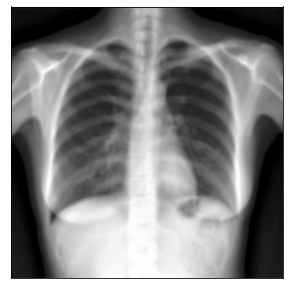

In [88]:
# Equalization
colorimage_eq = equalize(colorimage)
showimage(colorimage_eq)

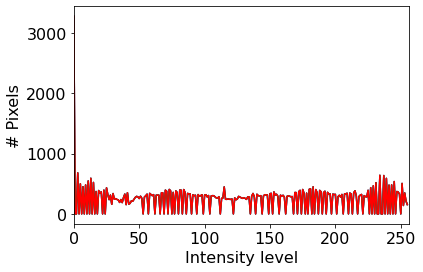

In [85]:
# Equalized histograms
color = ('b','g','r')
for i,col in enumerate(color):
    histr = cv2.calcHist([colorimage_eq],[i],None,[256],[0,256])
    plt.plot(histr,color = col)
    plt.xlim([0,256])
    plt.xlabel('Intensity level')
    plt.ylabel('# Pixels')
plt.show()


hist_eq = cv2.calcHist([colorimage_eq],[0],None,[256],[0,256])

(-0.5, 255.5, 255.5, -0.5)

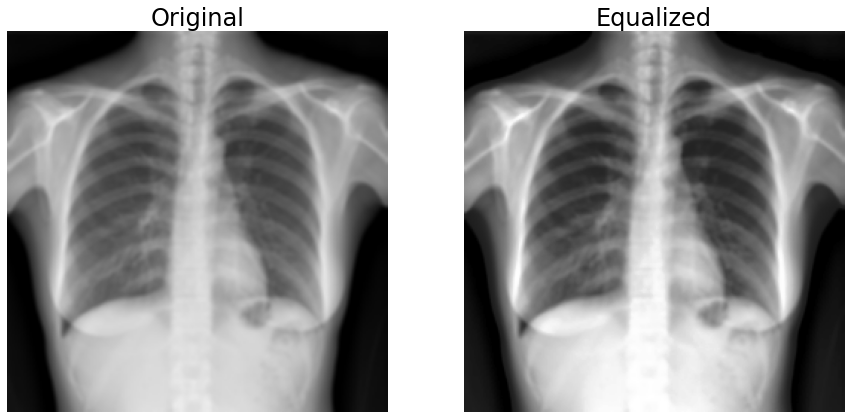

In [ ]:
# Comparison
fig, axs = plt.subplots(1, 2, figsize=(15,30))
axs[0].imshow(colorimage, cmap='gray')
axs[0].set_title('Original', fontsize = 24)
axs[0].axis('off')
axs[1].imshow(colorimage_eq, cmap='gray')
axs[1].set_title('Equalized', fontsize = 24)
axs[1].axis('off')